# Minha Primeira Rede Neural em PyTorch: MNIST do Zero


## Objetivo


Este projeto tem como objetivo construir e treinar minha **primeira rede neural utilizando PyTorch**, aplicando na prática os principais conceitos de Deep Learning: **tensors, forward pass, funções de ativação, loss, backpropagation e otimização**.

O problema escolhido é a classificação dos dígitos manuscritos do dataset **MNIST**, com classes de **0 a 9**.

## Metodologia


O fluxo utilizado será:

1. Carregar e visualizar o dataset MNIST.
2. Dividir os dados em **treino, validação e teste**.
3. Organizar os dados em batches com `DataLoader`.
4. Transformar cada imagem `28 × 28` em um vetor de `784` valores.
5. Construir uma **MLP (Multilayer Perceptron)** com PyTorch.
6. Treinar a rede utilizando:

   * `CrossEntropyLoss`
   * Backpropagation
   * Otimizador Adam
7. Acompanhar a evolução da **loss e acurácia**.
8. Avaliar o modelo no conjunto de teste.
9. Analisar exemplos classificados corretamente e exemplos em que o modelo errou.

### Arquitetura utilizada


```text
Imagem 28 × 28
      ↓
Flatten
      ↓
784 features
      ↓
Linear: 784 → 128
      ↓
ReLU
      ↓
Linear: 128 → 64
      ↓
ReLU
      ↓
Linear: 64 → 10
      ↓
Classe prevista: 0–9
```

> **Objetivo principal:** mais do que obter uma alta acurácia, este notebook busca entender de forma prática **como uma rede neural é construída e treinada no PyTorch**.


## Imports

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt



## Configs

In [2]:
batch_size = 64
learning_rate = 0.001
epochs = 10
seed = 42

torch.manual_seed(seed)

## DEVICE

In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"  # Mac com Apple Silicon
else:
    device = "cpu"

print("Device:", device)

Device: mps


## Dataset


In [4]:
transform = transforms.ToTensor()

dataset_completo = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataset_teste = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [5]:
imagem, label = dataset_completo[0]


print("\n================ UMA AMOSTRA ================")

print("Tipo da imagem:")
print(type(imagem))

print("\nShape:")
print(imagem.shape)

print("\nTipo dos dados:")
print(imagem.dtype)

print("\nLabel:")
print(label)

print("\nPixel mínimo:")
print(imagem.min().item())

print("\nPixel máximo:")
print(imagem.max().item())

print("\nPixel médio:")
print(imagem.mean().item())


================ UMA AMOSTRA ================
Tipo da imagem:
<class 'torch.Tensor'>

Shape:
torch.Size([1, 28, 28])

Tipo dos dados:
torch.float32

Label:
5

Pixel mínimo:
0.0

Pixel máximo:
1.0

Pixel médio:
0.1376800686120987


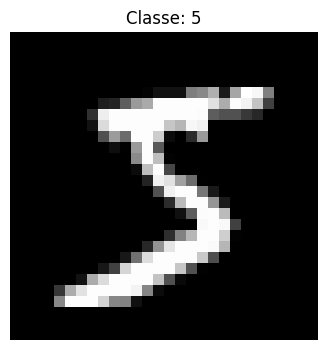

In [6]:
plt.figure(figsize=(4, 4))

plt.imshow(
    imagem.squeeze(),
    cmap="gray"
)

plt.title(f"Classe: {label}")

plt.axis("off")

plt.show()

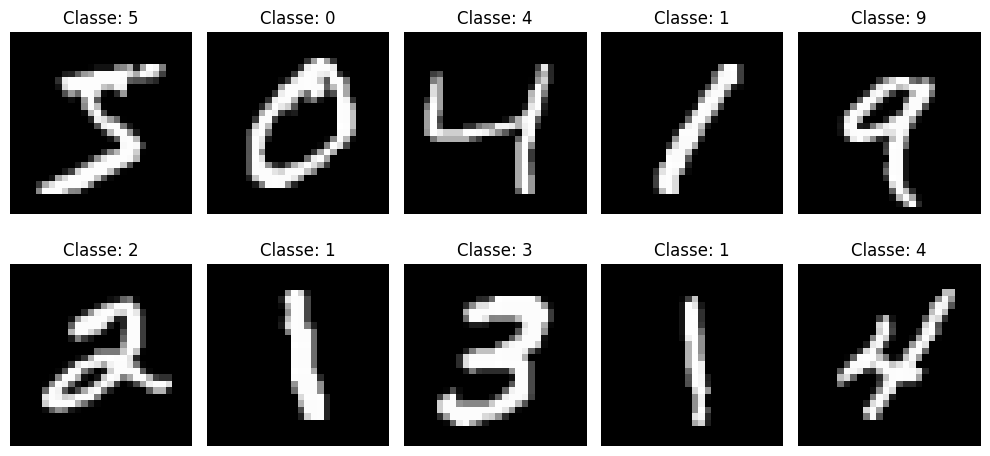

In [7]:
# ============================================================
# 5. VISUALIZANDO EXEMPLOS DO MNIST
# ============================================================

plt.figure(figsize=(10, 5))

for i in range(10):

    imagem, label = dataset_completo[i]

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        imagem.squeeze(),
        cmap="gray"
    )

    plt.title(f"Classe: {label}")

    plt.axis("off")


plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 6. DISTRIBUIÇÃO DAS CLASSES
# ============================================================

# Os labels originais do MNIST ficam em .targets

labels_treino = dataset_completo.targets


# Conta quantas vezes aparece cada classe

contagem_classes = torch.bincount(labels_treino)


print("\n================ CLASSES ================")

for classe, quantidade in enumerate(contagem_classes):

    print(
        f"Classe {classe}: "
        f"{quantidade.item()} exemplos"
    )
print(f'total de itens:{len(dataset_completo)}')


================ CLASSES ================
Classe 0: 5923 exemplos
Classe 1: 6742 exemplos
Classe 2: 5958 exemplos
Classe 3: 6131 exemplos
Classe 4: 5842 exemplos
Classe 5: 5421 exemplos
Classe 6: 5918 exemplos
Classe 7: 6265 exemplos
Classe 8: 5851 exemplos
Classe 9: 5949 exemplos
total de itens:60000


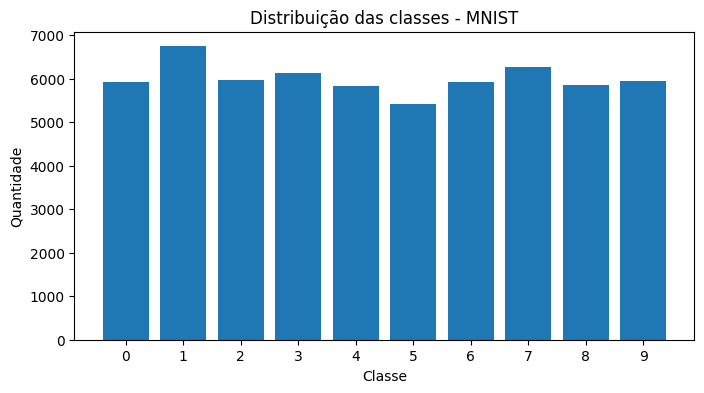

In [9]:
plt.figure(figsize=(8, 4))

plt.bar(
    range(10),
    contagem_classes.numpy()
)

plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.title("Distribuição das classes - MNIST")

plt.xticks(range(10))

plt.show()

## Divisão treino / validação


In [10]:
tamanho_total = len(dataset_completo)

# 80% para treino
tamanho_treino = int(0.8 * tamanho_total)

# 20% para validação
tamanho_validacao = tamanho_total - tamanho_treino


dataset_treino, dataset_validacao = random_split(

    dataset_completo,

    [tamanho_treino, tamanho_validacao],

    generator=torch.Generator().manual_seed(seed)
)


print("Treino:", len(dataset_treino))
print("Validação:", len(dataset_validacao))
print("Teste:", len(dataset_teste))

Treino: 48000
Validação: 12000
Teste: 10000


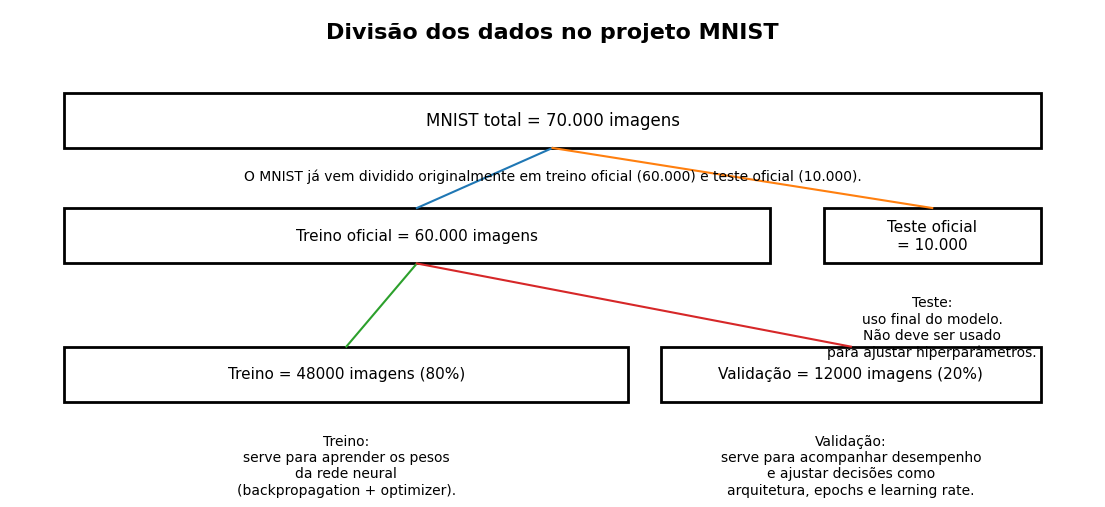

In [11]:
from matplotlib.patches import Rectangle

# ============================================================
# FIGURA ILUSTRATIVA DA DIVISÃO DOS DADOS
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Remove eixos
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis("off")

# Título
ax.text(
    50, 95,
    "Divisão dos dados no projeto MNIST",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

# -----------------------------
# Bloco 1: MNIST total
# -----------------------------
ax.add_patch(Rectangle((5, 70), 90, 12, fill=False, linewidth=2))
ax.text(
    50, 76,
    "MNIST total = 70.000 imagens",
    ha="center",
    va="center",
    fontsize=12
)

# Explicação embaixo
ax.text(
    50, 64,
    "O MNIST já vem dividido originalmente em treino oficial (60.000) e teste oficial (10.000).",
    ha="center",
    va="center",
    fontsize=10
)

# -----------------------------
# Bloco 2: treino oficial e teste oficial
# -----------------------------
# treino oficial
ax.add_patch(Rectangle((5, 45), 65, 12, fill=False, linewidth=2))
ax.text(
    37.5, 51,
    "Treino oficial = 60.000 imagens",
    ha="center",
    va="center",
    fontsize=11
)

# teste oficial
ax.add_patch(Rectangle((75, 45), 20, 12, fill=False, linewidth=2))
ax.text(
    85, 51,
    "Teste oficial\n= 10.000",
    ha="center",
    va="center",
    fontsize=11
)

# linhas
ax.plot([50, 37.5], [70, 57], linewidth=1.5)
ax.plot([50, 85], [70, 57], linewidth=1.5)

# explicação do teste
ax.text(
    85, 38,
    "Teste:\nuso final do modelo.\nNão deve ser usado\npara ajustar hiperparâmetros.",
    ha="center",
    va="top",
    fontsize=10
)

# -----------------------------
# Bloco 3: split treino/validação
# -----------------------------
# treino final
ax.add_patch(Rectangle((5, 15), 52, 12, fill=False, linewidth=2))
ax.text(
    31, 21,
    f"Treino = {tamanho_treino} imagens (80%)",
    ha="center",
    va="center",
    fontsize=11
)

# validação final
ax.add_patch(Rectangle((60, 15), 35, 12, fill=False, linewidth=2))
ax.text(
    77.5, 21,
    f"Validação = {tamanho_validacao} imagens (20%)",
    ha="center",
    va="center",
    fontsize=11
)

# linhas a partir do treino oficial
ax.plot([37.5, 31], [45, 27], linewidth=1.5)
ax.plot([37.5, 77.5], [45, 27], linewidth=1.5)

# explicação treino
ax.text(
    31, 8,
    "Treino:\nserve para aprender os pesos\nda rede neural\n(backpropagation + optimizer).",
    ha="center",
    va="top",
    fontsize=10
)

# explicação validação
ax.text(
    77.5, 8,
    "Validação:\nserve para acompanhar desempenho\ne ajustar decisões como\narquitetura, epochs e learning rate.",
    ha="center",
    va="top",
    fontsize=10
)

plt.show()

## DataLoaders


In [12]:
# ============================================================
# DATALOADERS
# ============================================================

# O DataLoader organiza o dataset em pequenos grupos (batches)
# que serão enviados para o modelo durante treino/avaliação.
#
# Exemplo:
#
# dataset com 48.000 imagens
# batch_size = 64
#
# teremos aproximadamente:
#
# batch 1 -> 64 imagens
# batch 2 -> 64 imagens
# batch 3 -> 64 imagens
# ...
#
# Em cada batch o modelo atualiza os pesos

loader_treino = DataLoader(
    dataset_treino,
    batch_size=batch_size,
    # Embaralha os exemplos antes de cada epoch
    # Isso evita que o modelo veja os dados sempre
    # exatamente na mesma ordem.
    shuffle=True
)

loader_validacao = DataLoader(
    dataset_validacao,
    batch_size=batch_size,
    # Não precisamos embaralhar porque:
    # - os pesos NÃO são atualizados
    # - queremos apenas calcular métricas
    # - a ordem dos exemplos não altera o resultado final
    shuffle=False
)

loader_teste = DataLoader(
    dataset_teste,
    batch_size=batch_size,
    # Também não precisamos embaralhar.
    # O modelo apenas faz previsões e calculamos
    # as métricas finais.
    shuffle=False
)

In [13]:
# ============================================================
#ENTENDENDO UM BATCH
# ============================================================

X_batch, y_batch = next(iter(loader_treino))


print("\n================ BATCH ================")

print("Shape de X:")
print(X_batch.shape)

print("\nShape de y:")
print(y_batch.shape)

print("\nPrimeiros labels:")
print(y_batch[:])


================ BATCH ================
Shape de X:
torch.Size([64, 1, 28, 28])

Shape de y:
torch.Size([64])

Primeiros labels:
tensor([8, 6, 5, 8, 6, 3, 0, 8, 0, 0, 7, 5, 2, 1, 3, 7, 2, 7, 5, 8, 9, 7, 6, 6,
        9, 4, 2, 0, 6, 5, 4, 0, 4, 1, 7, 6, 6, 4, 0, 6, 2, 2, 8, 4, 3, 9, 7, 2,
        6, 6, 3, 7, 6, 6, 5, 0, 9, 5, 0, 7, 4, 5, 0, 7])



Quantidade de imagens no batch:
64


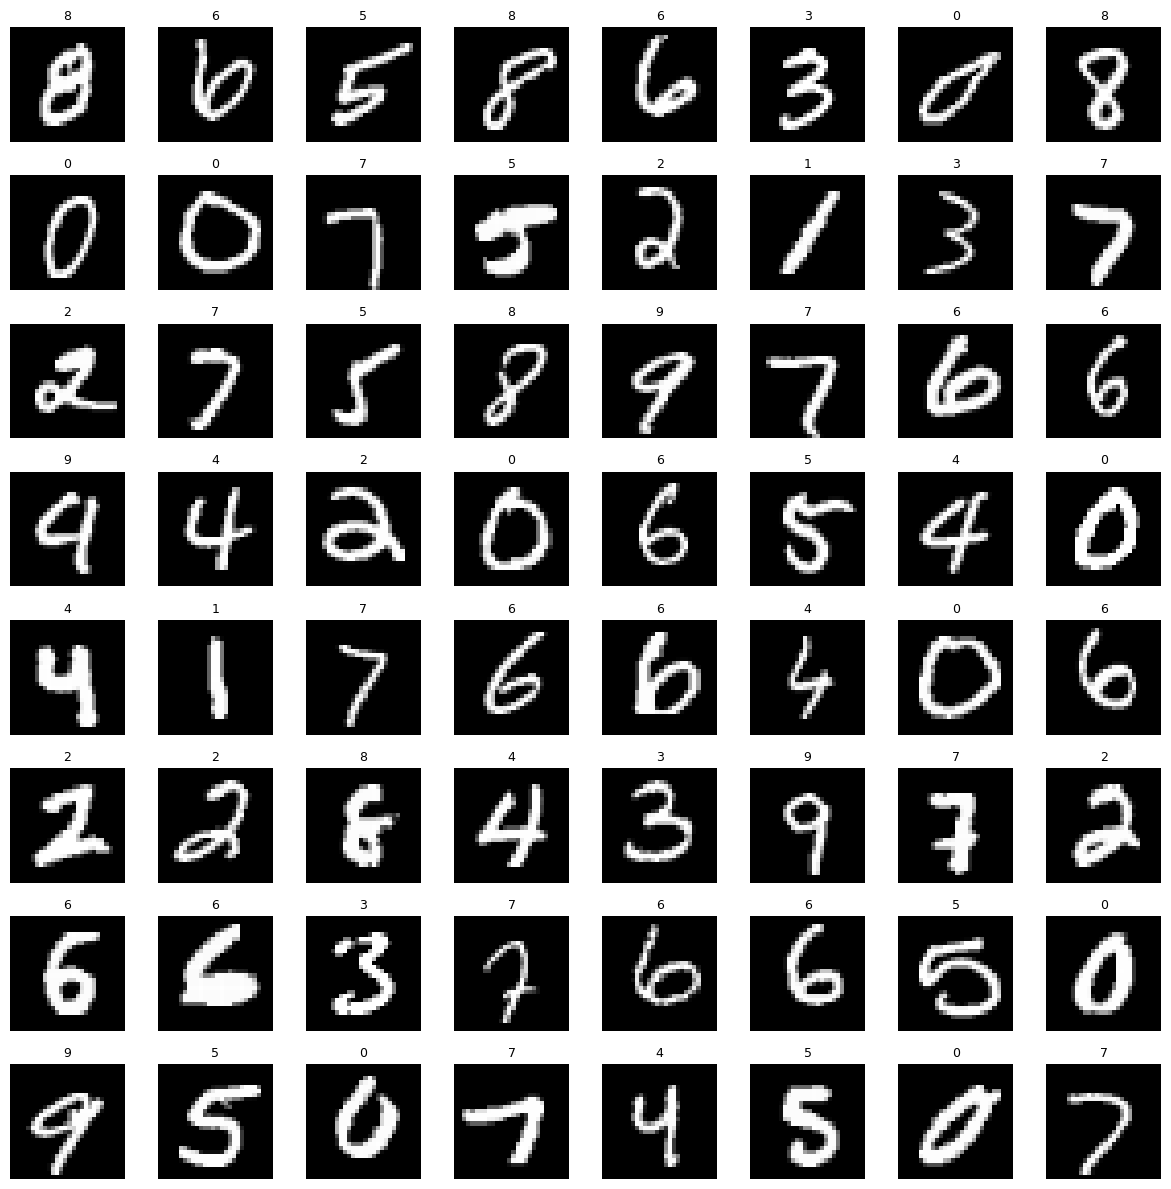

In [14]:
# ============================================================
# VISUALIZANDO TODAS AS IMAGENS DO BATCH
# ============================================================

# Quantidade de imagens no batch
quantidade_imagens = len(X_batch)

print("\nQuantidade de imagens no batch:")
print(quantidade_imagens)


# Como batch_size = 64,
# vamos organizar em uma grade 8 x 8

colunas = 8

# Calcula automaticamente a quantidade de linhas necessária
linhas = (quantidade_imagens + colunas - 1) // colunas


# Figura maior para comportar todas as imagens
plt.figure(
    figsize=(12, 12)
)


# Percorre TODAS as imagens do batch
for i in range(quantidade_imagens):

    # Cria uma posição na grade
    plt.subplot(
        linhas,
        colunas,
        i + 1
    )

    # X_batch[i] possui shape:
    #
    # [1, 28, 28]
    #
    # squeeze() transforma em:
    #
    # [28, 28]
    #
    # para o matplotlib conseguir mostrar a imagem
    plt.imshow(
        X_batch[i].squeeze(),
        cmap="gray"
    )

    # Mostra o label verdadeiro
    plt.title(
        f"{y_batch[i].item()}",
        fontsize=9
    )

    # Remove os eixos para deixar mais limpo
    plt.axis("off")


# Ajusta os espaçamentos
plt.tight_layout()

plt.show()

## MLP

Uma **MLP (Multilayer Perceptron)** é uma rede neural formada por várias camadas totalmente conectadas.

Neste projeto, cada imagem do MNIST possui dimensão:

[
28 \times 28
]

Antes de entrar na rede, a imagem é transformada em um vetor de:

[
28 \times 28 = 784
]

valores.

A arquitetura utilizada será:

```text
Imagem 28 × 28
      ↓
Flatten
      ↓
784 valores
      ↓
Linear (784 → 128)
      ↓
ReLU
      ↓
Linear (128 → 64)
      ↓
ReLU
      ↓
Linear (64 → 10)
      ↓
10 logits
      ↓
Classe prevista: 0–9
```

Cada camada `Linear` realiza uma transformação do tipo:

[
z = Wx + b
]

onde:

* (x) representa os dados de entrada;
* (W) representa os pesos aprendidos pela rede;
* (b) representa os biases.

Após as camadas intermediárias utilizamos a função de ativação **ReLU**:

[
ReLU(x) = \max(0,x)
]

Ela introduz **não linearidade**, permitindo que a rede aprenda relações mais complexas entre os pixels da imagem.

As camadas escondidas vão criando novas representações dos dados:

```text
784 pixels
    ↓
128 características aprendidas
    ↓
64 características aprendidas
    ↓
10 classes
```

A última camada possui **10 neurônios**, um para cada possível dígito do MNIST:

[
0,1,2,...,9
]

Sua saída são **logits**, que serão utilizados pela `CrossEntropyLoss` durante o treinamento.

> A ideia principal da MLP é transformar progressivamente a representação original da imagem em uma representação que torne fácil decidir qual dígito está presente.


In [15]:
#class MLP(nn.Module):
#
#    def __init__(self):
#        super().__init__()
#        #transforma a imagem 28x28 em um vetor de 784 elementos
#        self.flatten = nn.Flatten()
#
#        self.rede = nn.Sequential(
#
#            # 784 -> 128
#            nn.Linear(28 * 28, 128),
#            nn.ReLU(),
#
#            # 128 -> 64
#            nn.Linear(128, 64),
#            nn.ReLU(),
#
#            # 64 -> 10 classes
#            nn.Linear(64, 10)
#        )
#
#    def forward(self, x):
#
#        # [batch, 1, 28, 28]
#        x = self.flatten(x)
#
#        # [batch, 784]
#        logits = self.rede(x)
#
#        # [batch, 10]
#        return logits

# ============================================================
# MLP
# ============================================================

class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        #transforma a imagem 28x28 em um vetor de 784 elementos
        self.flatten = nn.Flatten()

        # 784 -> 128
        self.linear1 = nn.Linear(
            28 * 28,
            128
        )
        self.relu1 = nn.ReLU()

        # Vamos considerar essa representação
        # de 64 dimensões como o "embedding"
        # aprendido pela MLP.
        # 128 -> 64
        self.linear2 = nn.Linear(
            128,
            64
        )

        self.relu2 = nn.ReLU()

        # 64 -> 10 classes
        self.output = nn.Linear(
            64,
            10
        )

    def forward(self, x):


        x = self.flatten(x)

        x = self.linear1(x)

        x = self.relu1(x)

        x = self.linear2(x)

        embedding = self.relu2(x)

        logits = self.output(embedding)

        return logits

    def get_embedding(self, x):

        # Repete o forward apenas até
        # a última camada escondida.

        x = self.flatten(x)

        x = self.linear1(x)
        x = self.relu1(x)

        x = self.linear2(x)

        embedding = self.relu2(x)

        return embedding

modelo = MLP().to(device)

print(modelo)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (linear2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=64, out_features=10, bias=True)
)


In [16]:
# ============================================================
# 11. PARÂMETROS DO MODELO
# ============================================================

print("\n================ PARÂMETROS ================")


total_parametros = 0


for nome, parametro in modelo.named_parameters():

    quantidade = parametro.numel()

    total_parametros += quantidade


    print(
        f"{nome:20} "
        f"shape={str(list(parametro.shape)):18} "
        f"params={quantidade}"
    )


print("\nTotal de parâmetros treináveis:")
print(f"{total_parametros:,}")


================ PARÂMETROS ================
linear1.weight       shape=[128, 784]         params=100352
linear1.bias         shape=[128]              params=128
linear2.weight       shape=[64, 128]          params=8192
linear2.bias         shape=[64]               params=64
output.weight        shape=[10, 64]           params=640
output.bias          shape=[10]               params=10

Total de parâmetros treináveis:
109,386


In [17]:
# ============================================================
# INSPECIONANDO OS PARÂMETROS INICIAIS
# ============================================================


# ============================================================
# LINEAR 1
# ============================================================

print("\n=========== LINEAR 1 ===========")

print("Shape dos pesos:")
print(modelo.linear1.weight.shape)

print("\nShape dos biases:")
print(modelo.linear1.bias.shape)

print("\n10 primeiros pesos do primeiro neurônio:")
print(
    modelo.linear1.weight[0, :10]
)

print("\nBias dos 10 primeiros neurônios:")
print(
    modelo.linear1.bias[:10]
)


# ============================================================
# LINEAR 2
# ============================================================

print("\n=========== LINEAR 2 ===========")

print("Shape dos pesos:")
print(modelo.linear2.weight.shape)

print("\nShape dos biases:")
print(modelo.linear2.bias.shape)

print("\n10 primeiros pesos do primeiro neurônio:")
print(
    modelo.linear2.weight[0, :10]
)

print("\nBias dos 10 primeiros neurônios:")
print(
    modelo.linear2.bias[:10]
)


# ============================================================
# OUTPUT
# ============================================================

print("\n=========== OUTPUT ===========")

print("Shape dos pesos:")
print(modelo.output.weight.shape)

print("\nShape dos biases:")
print(modelo.output.bias.shape)

print("\n10 primeiros pesos do primeiro neurônio de saída:")
print(
    modelo.output.weight[0, :10]
)

print("\nBias das 10 classes de saída:")
print(
    modelo.output.bias
)


=========== LINEAR 1 ===========
Shape dos pesos:
torch.Size([128, 784])

Shape dos biases:
torch.Size([128])

10 primeiros pesos do primeiro neurônio:
tensor([-0.0078,  0.0072, -0.0174,  0.0210,  0.0315, -0.0262,  0.0310,  0.0067,
         0.0264,  0.0048], device='mps:0', grad_fn=<SliceBackward0>)

Bias dos 10 primeiros neurônios:
tensor([-0.0329,  0.0218,  0.0336, -0.0083, -0.0081, -0.0060, -0.0015,  0.0339,
         0.0147, -0.0304], device='mps:0', grad_fn=<SliceBackward0>)

=========== LINEAR 2 ===========
Shape dos pesos:
torch.Size([64, 128])

Shape dos biases:
torch.Size([64])

10 primeiros pesos do primeiro neurônio:
tensor([ 0.0373,  0.0304, -0.0256,  0.0310,  0.0150, -0.0376, -0.0812, -0.0837,
        -0.0153, -0.0299], device='mps:0', grad_fn=<SliceBackward0>)

Bias dos 10 primeiros neurônios:
tensor([-0.0586,  0.0615, -0.0532,  0.0090,  0.0092, -0.0513,  0.0831,  0.0815,
        -0.0425,  0.0658], device='mps:0', grad_fn=<SliceBackward0>)

=========== OUTPUT ===========


## Loss e optimizer

In [18]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    modelo.parameters(),
    lr=learning_rate
)

print("\nLoss function:")
print(loss_fn)

print("\nOptimizer:")
print(optimizer)


Loss function:
CrossEntropyLoss()

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Visulizando uma atualização dos parametros (MODO DEBUG)

In [19]:
# ============================================================
# DEBUG: UM PASSO COMPLETO DE TREINAMENTO
# forward -> loss -> backward -> Adam -> novos pesos
# ============================================================

# Coloca o modelo em modo de treinamento
modelo.train()


# ============================================================
# 1. PEGANDO UM ÚNICO BATCH
# ============================================================

X, y = next(iter(loader_treino))

X = X.to(device)
y = y.to(device)


print("\n================ 1. BATCH ================")

print("Shape X:")
print(X.shape)

print("\nShape y:")
print(y.shape)

print("\nPrimeiros labels:")
print(y[:10])


# ============================================================
# 2. ESCOLHENDO UM PESO PARA ACOMPANHAR
# ============================================================

# Vamos acompanhar:
#
# primeiro neurônio da primeira camada
# primeiro peso desse neurônio
#
# W1[0,406]

linha = 0
coluna = 406


peso_antes = (
    modelo.linear1
    .weight[linha, coluna]
    .detach()
    .item()
)


bias_antes = (
    modelo.linear1
    .bias[linha]
    .detach()
    .item()
)


print("\n================ 2. PARÂMETRO INICIAL ================")

print(f"W1[{linha},{coluna}] antes:")
print(peso_antes)

print(f"\nb1[{linha}] antes:")
print(bias_antes)


================ 1. BATCH ================
Shape X:
torch.Size([64, 1, 28, 28])

Shape y:
torch.Size([64])

Primeiros labels:
tensor([5, 8, 1, 5, 1, 1, 4, 9, 2, 1], device='mps:0')

================ 2. PARÂMETRO INICIAL ================
W1[0,406] antes:
-0.010396813042461872

b1[0] antes:
-0.032895397394895554


In [20]:
# ============================================================
# 3. FORWARD PASS
# ============================================================

# Matematicamente nossa rede faz:
#
# x
# ↓
# z1 = W1*x + b1
# ↓
# h1 = ReLU(z1)
# ↓
# z2 = W2*h1 + b2
# ↓
# h2 = ReLU(z2)
# ↓
# logits = W3*h2 + b3


logits = modelo(X)


print("\n================ 3. FORWARD ================")

print("Shape dos logits:")
print(logits.shape)


print("\nLogits da primeira imagem:")
print(logits[0].detach().cpu())


# Transformamos em probabilidades apenas para visualização.
# NÃO usamos esse softmax para calcular CrossEntropyLoss.

probabilidades = torch.softmax(
    logits,
    dim=1
)


print("\nProbabilidades da primeira imagem:")

for classe, prob in enumerate(
    probabilidades[0].detach().cpu()
):

    print(
        f"Classe {classe}: {prob.item():.2%}"
    )


print("\nClasse real:")
print(y[0].item())


print("\nClasse prevista:")
print(
    logits[0]
    .argmax()
    .item()
)


================ 3. FORWARD ================
Shape dos logits:
torch.Size([64, 10])

Logits da primeira imagem:
tensor([ 0.0765,  0.0033, -0.0126, -0.0745, -0.0889,  0.0491,  0.0772,  0.1378,
         0.1097,  0.0343])

Probabilidades da primeira imagem:
Classe 0: 10.44%
Classe 1: 9.70%
Classe 2: 9.55%
Classe 3: 8.97%
Classe 4: 8.85%
Classe 5: 10.16%
Classe 6: 10.44%
Classe 7: 11.10%
Classe 8: 10.79%
Classe 9: 10.01%

Classe real:
5

Classe prevista:
7


In [21]:
# ============================================================
# 4. LOSS
# ============================================================

loss = loss_fn(
    logits,
    y
)


print("\n================ 4. LOSS ================")

print("CrossEntropyLoss:")
print(loss.item())


================ 4. LOSS ================
CrossEntropyLoss:
2.304701089859009


In [22]:
# ============================================================
# 5. ZERANDO GRADIENTES ANTIGOS
# ============================================================

optimizer.zero_grad()


print("\n================ 5. ANTES DO BACKWARD ================")

print(
    "Gradiente de linear1.weight:"
)

print(
    modelo.linear1.weight.grad
)


================ 5. ANTES DO BACKWARD ================
Gradiente de linear1.weight:
None


In [23]:
# ============================================================
# 6. BACKPROPAGATION
# ============================================================

loss.backward()

In [24]:
print("\n================ 6. BACKPROP ================")


gradiente_peso = (
    modelo.linear1
    .weight
    .grad[linha, coluna]
    .item()
)


gradiente_bias = (
    modelo.linear1
    .bias
    .grad[linha]
    .item()
)


print(
    f"dL/dW1[{linha},{coluna}]:"
)

print(
    gradiente_peso
)


print(
    f"\ndL/db1[{linha}]:"
)

print(
    gradiente_bias
)


================ 6. BACKPROP ================
dL/dW1[0,406]:
-0.0008966254536062479

dL/db1[0]:
-0.0022381858434528112


In [25]:
print("\n================ GRADIENTES DAS CAMADAS ================")


print(
    "Norma do gradiente W1:",
    modelo.linear1.weight.grad.norm().item()
)


print(
    "Norma do gradiente W2:",
    modelo.linear2.weight.grad.norm().item()
)


print(
    "Norma do gradiente W3:",
    modelo.output.weight.grad.norm().item()
)


================ GRADIENTES DAS CAMADAS ================
Norma do gradiente W1: 0.24213840067386627
Norma do gradiente W2: 0.09163065254688263
Norma do gradiente W3: 0.0736326202750206


In [26]:
# ============================================================
# 7. UPDATE HIPOTÉTICO COM SGD
# ============================================================

peso_sgd_teorico = (
    peso_antes
    -
    learning_rate * gradiente_peso
)


print("\n================ SGD TEÓRICO ================")

print("Peso antes:")
print(peso_antes)

print("\nLearning rate:")
print(learning_rate)

print("\nGradiente:")
print(gradiente_peso)

print("\nCálculo:")

print(
    f"{peso_antes:.8f} "
    f"- {learning_rate} * ({gradiente_peso:.8f})"
)

print("\nPeso se usássemos SGD simples:")

print(
    peso_sgd_teorico
)


================ SGD TEÓRICO ================
Peso antes:
-0.010396813042461872

Learning rate:
0.001

Gradiente:
-0.0008966254536062479

Cálculo:
-0.01039681 - 0.001 * (-0.00089663)

Peso se usássemos SGD simples:
-0.010395916417008266


In [27]:
# ============================================================
# 8. ADAM
# ============================================================

optimizer.step()

In [28]:
peso_depois = (
    modelo.linear1
    .weight[linha, coluna]
    .detach()
    .item()
)


bias_depois = (
    modelo.linear1
    .bias[linha]
    .detach()
    .item()
)


print("\n================ 8. PESOS APÓS ADAM ================")

print("Peso antes:")
print(peso_antes)


print("\nPeso depois:")
print(peso_depois)


print("\nMudança real:")

print(
    peso_depois - peso_antes
)


print("\nBias antes:")
print(bias_antes)


print("\nBias depois:")
print(bias_depois)


================ 8. PESOS APÓS ADAM ================
Peso antes:
-0.010396813042461872

Peso depois:
-0.009396824054419994

Mudança real:
0.0009999889880418777

Bias antes:
-0.032895397394895554

Bias depois:
-0.03189540281891823


In [29]:
print("\n================ RESUMO ================")

print(f"Loss:                 {loss.item():.6f}")

print(
    f"Peso inicial:         "
    f"{peso_antes:.8f}"
)

print(
    f"Gradiente dL/dW:      "
    f"{gradiente_peso:.8f}"
)

print(
    f"SGD teórico:          "
    f"{peso_sgd_teorico:.8f}"
)

print(
    f"Peso após Adam:       "
    f"{peso_depois:.8f}"
)

print(
    f"Alteração pelo Adam:  "
    f"{peso_depois - peso_antes:.8f}"
)


================ RESUMO ================
Loss:                 2.304701
Peso inicial:         -0.01039681
Gradiente dL/dW:      -0.00089663
SGD teórico:          -0.01039592
Peso após Adam:       -0.00939682
Alteração pelo Adam:  0.00099999


## Função de treino


In [30]:
def treinar(loader, modelo, loss_fn, optimizer):

    modelo.train()

    loss_total = 0
    corretos = 0
    total = 0

    for X, y in loader:

        X = X.to(device)
        y = y.to(device)

        # --------------------------------
        # FORWARD
        # --------------------------------

        logits = modelo(X)

        # --------------------------------
        # LOSS
        # --------------------------------

        loss = loss_fn(logits, y)

        # --------------------------------
        # BACKPROPAGATION
        # --------------------------------

        optimizer.zero_grad()

        loss.backward()

        # --------------------------------
        # GRADIENT DESCENT / OPTIMIZER
        # --------------------------------

        optimizer.step()

        # --------------------------------
        # Métricas
        # --------------------------------

        loss_total += loss.item() * X.size(0)

        predicoes = logits.argmax(dim=1)

        corretos += (predicoes == y).sum().item()
        total += y.size(0)

    loss_media = loss_total / total
    acuracia = corretos / total

    return loss_media, acuracia

## Validação

In [31]:
def avaliar(loader, modelo, loss_fn):

    modelo.eval()

    loss_total = 0
    corretos = 0
    total = 0

    # Não precisamos de gradientes durante avaliação
    with torch.no_grad():

        for X, y in loader:

            X = X.to(device)
            y = y.to(device)

            logits = modelo(X)

            loss = loss_fn(logits, y)

            loss_total += loss.item() * X.size(0)

            predicoes = logits.argmax(dim=1)

            corretos += (predicoes == y).sum().item()
            total += y.size(0)

    loss_media = loss_total / total
    acuracia = corretos / total

    return loss_media, acuracia

## Loop de Treinamento

In [32]:
historico = {

    "train_loss": [],

    "val_loss": [],

    "train_acc": [],

    "val_acc": []
}

In [33]:
# ============================================================
# 18. TREINAMENTO
# ============================================================

print("\n================ TREINAMENTO ================\n")


for epoch in range(epochs):

    loss_treino, acc_treino = treinar(
        loader_treino,
        modelo,
        loss_fn,
        optimizer
    )


    loss_val, acc_val = avaliar(
        loader_validacao,
        modelo,
        loss_fn
    )


    # Guardando histórico

    historico["train_loss"].append(
        loss_treino
    )

    historico["val_loss"].append(
        loss_val
    )

    historico["train_acc"].append(
        acc_treino
    )

    historico["val_acc"].append(
        acc_val
    )


    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train Loss: {loss_treino:.4f} | "
        f"Train Acc: {acc_treino:.2%} | "
        f"Val Loss: {loss_val:.4f} | "
        f"Val Acc: {acc_val:.2%}"
    )
    


================ TREINAMENTO ================

Epoch 01/10 | Train Loss: 0.3646 | Train Acc: 89.97% | Val Loss: 0.2204 | Val Acc: 93.62%
Epoch 02/10 | Train Loss: 0.1533 | Train Acc: 95.54% | Val Loss: 0.1419 | Val Acc: 95.73%
Epoch 03/10 | Train Loss: 0.1065 | Train Acc: 96.80% | Val Loss: 0.1178 | Val Acc: 96.47%
Epoch 04/10 | Train Loss: 0.0812 | Train Acc: 97.51% | Val Loss: 0.1047 | Val Acc: 96.85%
Epoch 05/10 | Train Loss: 0.0613 | Train Acc: 98.05% | Val Loss: 0.0977 | Val Acc: 97.19%
Epoch 06/10 | Train Loss: 0.0488 | Train Acc: 98.46% | Val Loss: 0.1070 | Val Acc: 96.88%
Epoch 07/10 | Train Loss: 0.0393 | Train Acc: 98.78% | Val Loss: 0.1068 | Val Acc: 96.73%
Epoch 08/10 | Train Loss: 0.0333 | Train Acc: 98.91% | Val Loss: 0.0992 | Val Acc: 97.25%
Epoch 09/10 | Train Loss: 0.0268 | Train Acc: 99.14% | Val Loss: 0.1213 | Val Acc: 96.79%
Epoch 10/10 | Train Loss: 0.0232 | Train Acc: 99.24% | Val Loss: 0.1147 | Val Acc: 96.87%


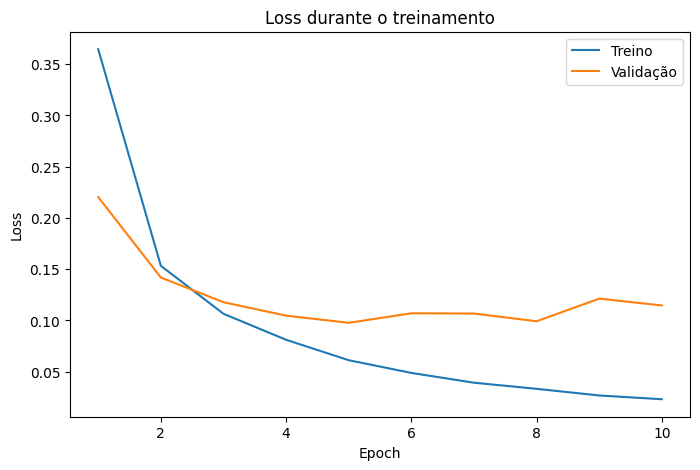

In [34]:
# ============================================================
# 19. CURVA DA LOSS
# ============================================================

plt.figure(figsize=(8, 5))


plt.plot(
    range(1, epochs + 1),
    historico["train_loss"],
    label="Treino"
)


plt.plot(
    range(1, epochs + 1),
    historico["val_loss"],
    label="Validação"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss durante o treinamento")

plt.legend()

plt.show()

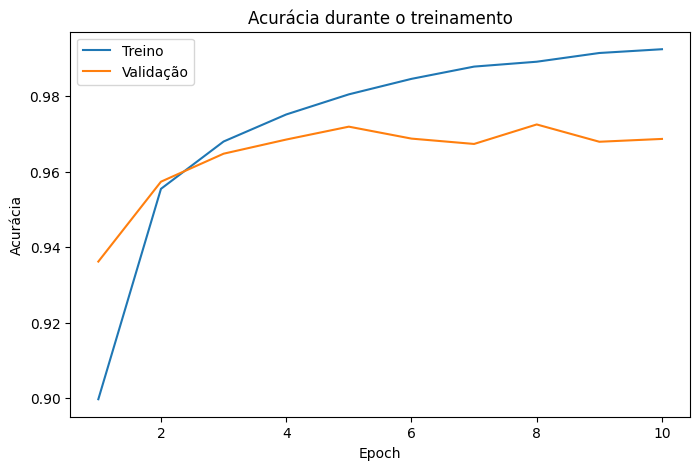

In [35]:
# ============================================================
# 20. CURVA DA ACURÁCIA
# ============================================================

plt.figure(figsize=(8, 5))


plt.plot(
    range(1, epochs + 1),
    historico["train_acc"],
    label="Treino"
)


plt.plot(
    range(1, epochs + 1),
    historico["val_acc"],
    label="Validação"
)


plt.xlabel("Epoch")
plt.ylabel("Acurácia")

plt.title("Acurácia durante o treinamento")

plt.legend()

plt.show()

## Avaliação final no teste


In [36]:
loss_teste, acc_teste = avaliar(
    loader_teste,
    modelo,
    loss_fn
)

print("\nResultado final:")
print(f"Test Loss: {loss_teste:.4f}")
print(f"Test Accuracy: {acc_teste:.4f}")


Resultado final:
Test Loss: 0.0973
Test Accuracy: 0.9740


In [37]:
# ============================================================
# 22. PREVISÃO INDIVIDUAL
# ============================================================

modelo.eval()


imagem, label_real = dataset_teste[0]


imagem_batch = (
    imagem
    .unsqueeze(0)
    .to(device)
)


with torch.no_grad():

    logits = modelo(
        imagem_batch
    )


    probabilidades = torch.softmax(
        logits,
        dim=1
    )


classe_prevista = (
    probabilidades
    .argmax(dim=1)
    .item()
)


print("\n================ PREVISÃO ================")

print("Classe real:")
print(label_real)

print("\nLogits:")
print(logits.cpu())

print("\nProbabilidades:")

for classe, prob in enumerate(
    probabilidades[0].cpu()
):

    print(
        f"{classe}: {prob.item():.2%}"
    )


print("\nClasse prevista:")
print(classe_prevista)


================ PREVISÃO ================
Classe real:
7

Logits:
tensor([[ -7.6586,  -6.0431,  -2.4543,   1.3124, -14.9258,  -6.5244, -21.2153,
          13.1981,  -6.2604,  -0.3416]])

Probabilidades:
0: 0.00%
1: 0.00%
2: 0.00%
3: 0.00%
4: 0.00%
5: 0.00%
6: 0.00%
7: 100.00%
8: 0.00%
9: 0.00%

Classe prevista:
7


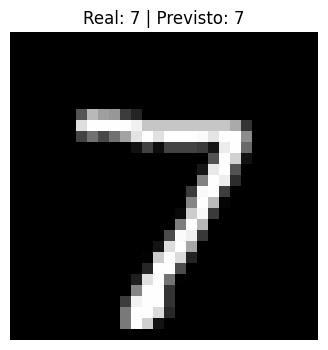

In [38]:
plt.figure(figsize=(4, 4))

plt.imshow(
    imagem.squeeze(),
    cmap="gray"
)

plt.title(
    f"Real: {label_real} | "
    f"Previsto: {classe_prevista}"
)

plt.axis("off")

plt.show()

In [39]:
# ============================================================
# 23. MATRIZ DE CONFUSÃO
# ============================================================

matriz_confusao = torch.zeros(
    10,
    10,
    dtype=torch.int64
)


modelo.eval()


with torch.no_grad():

    for X, y in loader_teste:

        X = X.to(device)

        logits = modelo(X)

        predicoes = logits.argmax(
            dim=1
        )


        # Voltamos para CPU para análise

        predicoes = predicoes.cpu()


        for real, previsto in zip(
            y,
            predicoes
        ):

            matriz_confusao[
                real,
                previsto
            ] += 1

print("\n================ MATRIZ DE CONFUSÃO ================")

print(matriz_confusao)


================ MATRIZ DE CONFUSÃO ================
tensor([[ 971,    0,    1,    1,    0,    2,    2,    1,    2,    0],
        [   0, 1127,    0,    2,    0,    1,    1,    1,    3,    0],
        [   5,    5,  967,   36,    2,    0,    1,   13,    3,    0],
        [   0,    0,    0,  994,    1,    4,    0,    4,    2,    5],
        [   1,    2,    1,    0,  959,    1,    6,    2,    1,    9],
        [   2,    0,    0,   12,    2,  864,    5,    0,    3,    4],
        [   5,    3,    1,    1,    2,    1,  944,    1,    0,    0],
        [   1,    4,    4,    8,    1,    0,    0, 1005,    0,    5],
        [   6,    1,    2,   14,    4,    6,    0,    2,  932,    7],
        [   2,    3,    1,    7,   12,    1,    0,    5,    1,  977]])


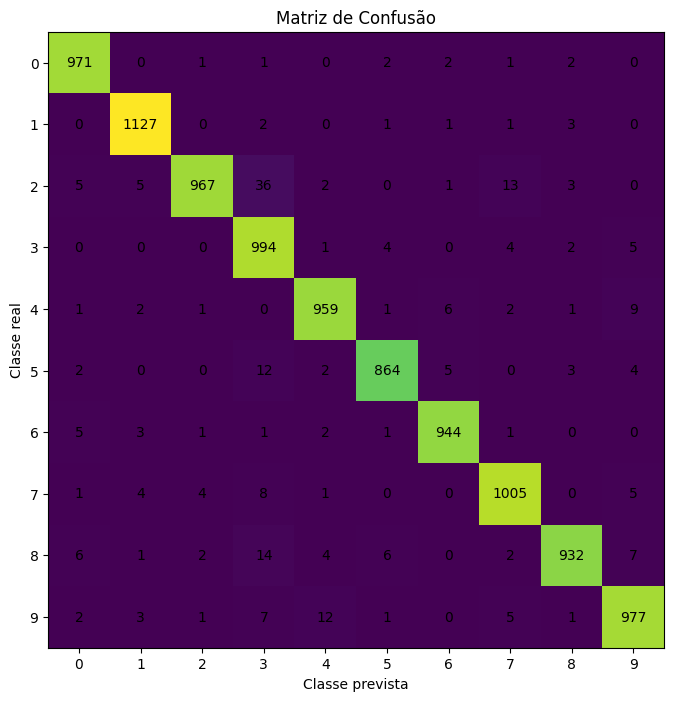

In [40]:
plt.figure(figsize=(8, 8))

plt.imshow(
    matriz_confusao.numpy()
)

plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.title("Matriz de Confusão")

plt.xticks(range(10))
plt.yticks(range(10))


for i in range(10):

    for j in range(10):

        valor = matriz_confusao[i, j].item()

        plt.text(
            j,
            i,
            valor,
            ha="center",
            va="center"
        )


plt.show()

In [41]:
# ============================================================
# 24. EXEMPLOS ERRADOS
# ============================================================

modelo.eval()


erros = []


with torch.no_grad():

    for X, y in loader_teste:

        X_device = X.to(device)


        logits = modelo(
            X_device
        )


        probabilidades = torch.softmax(
            logits,
            dim=1
        )


        predicoes = logits.argmax(
            dim=1
        )


        # Voltamos os resultados para CPU

        probabilidades = (
            probabilidades.cpu()
        )

        predicoes = (
            predicoes.cpu()
        )


        mascara_erros = (
            predicoes != y
        )


        for (
            imagem,
            real,
            previsto,
            probs
        ) in zip(

            X[mascara_erros],

            y[mascara_erros],

            predicoes[mascara_erros],

            probabilidades[mascara_erros]
        ):

            confianca = probs[
                previsto
            ].item()


            erros.append({

                "imagem": imagem,

                "real": real.item(),

                "previsto": previsto.item(),

                "confianca": confianca
            })


print("\n================ ERROS ================")

print(
    "Número de erros:",
    len(erros)
)

print(
    "Número de acertos:",
    len(dataset_teste) - len(erros)
)

print(
    "Taxa de erro:",
    f"{len(erros) / len(dataset_teste):.2%}"
)


================ ERROS ================
Número de erros: 260
Número de acertos: 9740
Taxa de erro: 2.60%


In [42]:
# Ordenamos do erro MAIS CONFIANTE
# para o MENOS CONFIANTE

erros_ordenados = sorted(

    erros,

    key=lambda x: x["confianca"],

    reverse=True
)

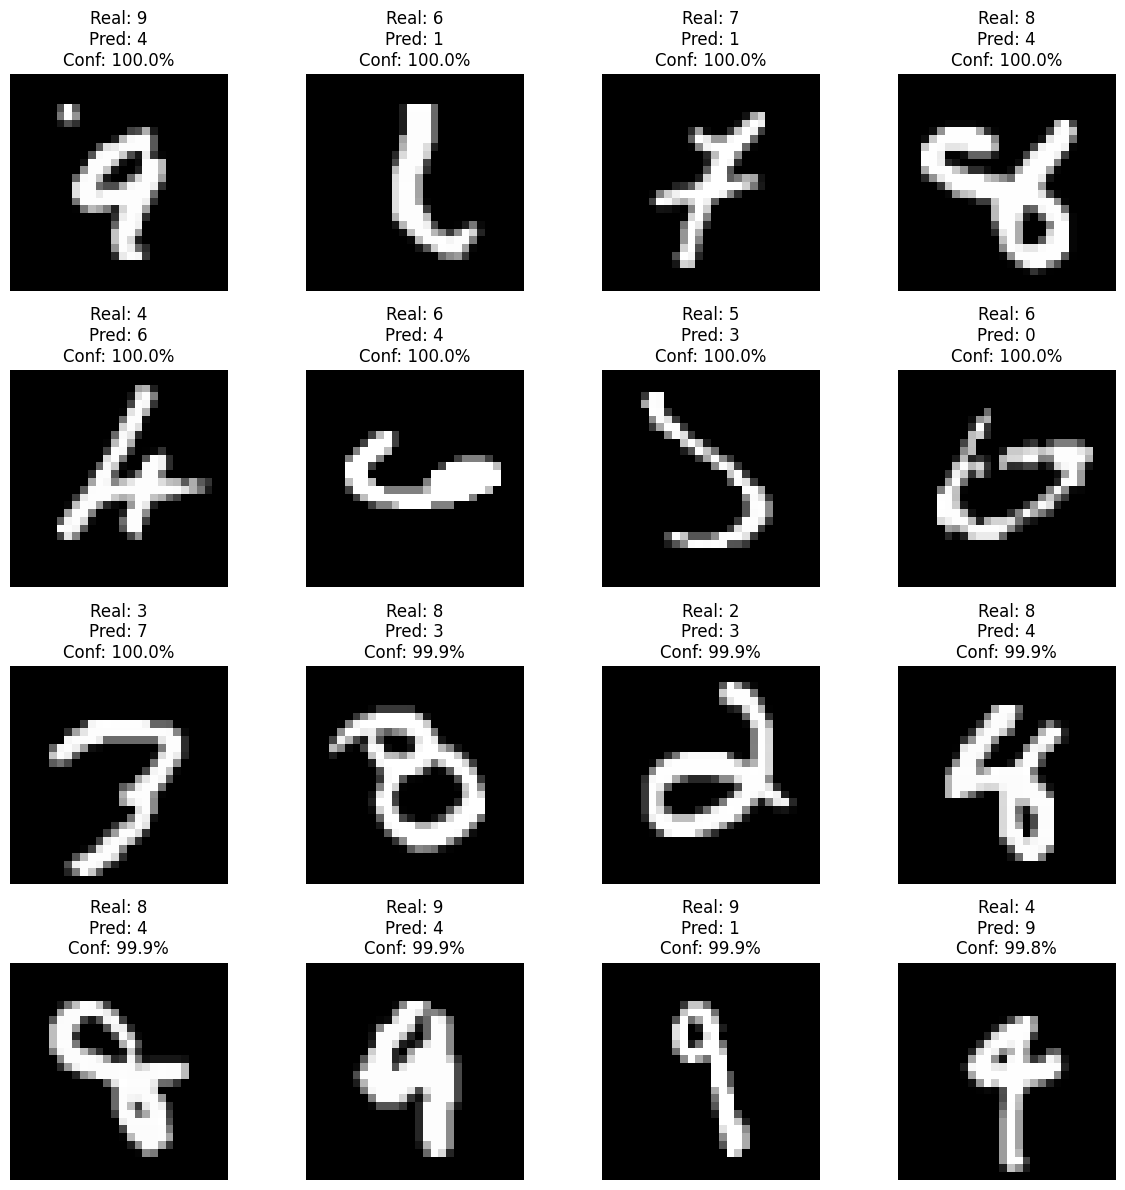

In [43]:
quantidade = 16


plt.figure(figsize=(12, 12))


for i, erro in enumerate(
    erros_ordenados[:quantidade]
):

    plt.subplot(
        4,
        4,
        i + 1
    )


    plt.imshow(
        erro["imagem"].squeeze(),
        cmap="gray"
    )


    plt.title(

        f"Real: {erro['real']}\n"

        f"Pred: {erro['previsto']}\n"

        f"Conf: {erro['confianca']:.1%}"
    )


    plt.axis("off")


plt.tight_layout()

plt.show()